# 실물 SO-101 팔 구동 (`08`의 혼합 디코더를 시뮬레이션 없이 실제 하드웨어로)

`neural-to-output` 프로젝트와 독립적인 sandbox입니다 (핵심 `src/n2o/`는 이 노트북에서 전혀
바뀌지 않습니다). `examples/08_mixed_classification_regression.ipynb`와 같은
`Decoder`/`Command`를 그대로 쓰되, **MuJoCo 시뮬레이션 대신 실제로 연결된 SO-101 팔을
구동**합니다.

**범위**: 이번엔 실물 **팔만** 다룹니다. 손(그리퍼)은 아직 실물이 연결되지 않았으므로
`n2o.robot.hand`는 아예 비워둡니다(`None`인 채로 둡니다) — 실물 그리퍼(또는 그 자리에 붙일
타사 로봇손)는 다음 단계에서 별도로 연동합니다.

## 사전 준비물

- `uv sync --group examples`로 `lerobot[feetech]`까지 설치되어 있어야 합니다
  (`pyproject.toml`의 `examples` 그룹, `[tool.uv.sources]`가 이 하드웨어 구성과 호환되는
  lerobot 포크/커밋을 가리킵니다).
- 이 팔은 그리퍼 모터가 없는 5-모터(id 1~5: `shoulder_pan`/`shoulder_lift`/`elbow_flex`/
  `wrist_flex`/`wrist_roll`) 구성이라, `lerobot`이 기본으로 제공하는 6모터 SO-101 클래스가
  아니라 그 구성에 맞춘 커스텀 로봇 플러그인 패키지 `lerobot_robot_so101_5dof`가 필요합니다.
  이 패키지는 이 저장소 밖(`/home/park/lerobot_robot_so101_5dof`)의 개인 하드웨어용 로컬
  패키지이므로 `pyproject.toml`에는 넣지 않았습니다 — `uv sync --group examples`를 실행한
  뒤, **한 번만** 아래를 실행해 이 프로젝트의 가상환경에 editable로 설치해 두세요 (참고: `uv
  sync`를 다시 실행하면 이 editable 설치가 초기화되므로 그때마다 다시 실행해야 합니다):

  ```bash
  uv pip install -e /home/park/lerobot_robot_so101_5dof
  ```

- 팔이 `SO101_PORT`(아래 상수)에 연결되어 있어야 합니다.
- **캘리브레이션은 노트북이 아니라 터미널에서 먼저 1회 끝내야 합니다** (자세한 이유는 1절
  참고 — Jupyter 커널의 stdin은 lerobot의 인터랙티브 캘리브레이션이 쓰는 raw-stdin
  `select()`와 호환되지 않습니다):

  ```bash
  uv run lerobot-calibrate --robot.type=so101_follower_5dof --robot.port=/dev/ttyACM1 --robot.id=n2o_so101_5dof
  ```

  팔을 손으로 움직여야 하니 물리적으로 팔 옆에서 실행하세요. 이미 캘리브레이션이 되어 있다면
  건너뛰어도 됩니다.

## 안전 주의사항

- 이 노트북은 **실제로 모터를 움직입니다**. 처음 실행할 때는 손을 팔 근처에 두고, 예상과 다르게
  움직이면 즉시 커널을 중단(interrupt)하세요.
- **팔 끝(gripperframe) 속도는 항상 1cm/s 이하로 제한됩니다** (`apply_arm_offset()`,
  5절) — 이동 거리에 비례해서 스텝 수를 늘려 평균 속도를 직접 상한선 아래로 강제합니다.
  `SO101Follower5DofConfig.max_relative_target=2.0`(관절당 한 번에 최대 2도)은 이게 뚫렸을
  때를 위한 2차 백스톱입니다. (초기 버전은 고정 스텝 수로 램프해서 이 상한이 실질적으로
  없었고, 그 때문에 관절이 예상 밖으로 거의 다 접히는 자세까지 움직인 적이 있습니다 — 5절
  마크다운에 원인을 적어뒀습니다.)
- 아래 각 섹션의 코드 셀은 실제 하드웨어와 통신합니다 (시뮬레이션이 아닙니다). 순서대로,
  한 번에 하나씩 실행하세요.

## 구조

`n2o.robot.Part`(`goal()`/`move()`)가 이전의 `RobotArm`/`RobotHand` + `Controller` 3단
구조를 대체합니다 — `goal()`은 순수 계산(하드웨어 접근 없음), `move()`가 실제 하드웨어를
구동합니다.

1. **`Decoder`** (`MixedDecoder`) — 손 제스처(분류) + 팔의 Cartesian 상대 이동량(회귀)을
   예측만 하는, 서로 독립된 두 모델. (`08`과 완전히 동일)
2. **`Command`** (`MixedCommand`) — 분류 결과는 이름으로, 회귀 결과는
   `(ActionType.CARTESIAN_RELATIVE, {...})`로 태그. (`08`과 완전히 동일)
3. **팔 구동** — `n2o.robot.arm.so101.SO101Arm`은 `"up"`/`"down"` 두 이산 제스처는
   `Part.move()`로 직접 구동하지만, 이 노트북의 `MixedCommand`가 만드는 Cartesian 상대
   이동량(`dx`, `dy`)은 아직 지원하지 않습니다(`ROADMAP.md`). 그래서 팔은
   `n2o.robot.arm.lerobot_robot_so101_5dof.solver.SO101IKSolver`로 직접 감쇠
   최소제곱(damped least squares) IK를 풀고("현재 위치"는 실물 `get_observation()`에서
   읽어 이 노트북이 직접 추적), 그 결과를 1절에서 이미 연결해 둔 저수준
   `arm.send_action()`으로 속도 제한(1cm/s)을 지키며 점진적으로 전송합니다 (5절).

In [ ]:
import time

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import torch
from lerobot_robot_so101_5dof import SO101Follower5Dof, SO101Follower5DofConfig

from n2o import N2O
from n2o.command import ActionType, Command, CommandConfig
from n2o.decoder import Decoder, DecoderConfig, DecoderType, FeatureType
from n2o.robot.arm.lerobot_robot_so101_5dof.solver import SO101IKSolver
from n2o.robot.arm.so101 import SO101Arm

ARM_JOINTS = [
    "shoulder_pan",
    "shoulder_lift",
    "elbow_flex",
    "wrist_flex",
    "wrist_roll",
]  # 08의 ARM_JOINTS에서 "gripper"만 뺀 목록 -- 이 팔엔 그리퍼 모터가 없습니다.
IK_JOINTS = ["shoulder_pan", "shoulder_lift", "elbow_flex"]
HAND_LABELS = ["grip", "release"]

SO101_PORT = "/dev/ttyACM3"
SO101_ROBOT_ID = "n2o_so101_5dof"  # 캘리브레이션 파일 이름(<id>.json)을 구분하는 용도

ik_solver = SO101IKSolver()  # 2절 슬라이더의 가동범위 조회 + 5절의 IK 계산이 함께 재사용합니다
# (기본 x_range=(0.26, 0.34)/y_range=(-0.10, 0.10)/z=0.15는 3절의 ARM_X_RANGE/ARM_Y_RANGE/ARM_Z와 동일)

## 1. 하드웨어 연결 및 구동 확인

가장 먼저 실물 팔과 통신이 되는지, 그리고 명령을 보내면 실제로 움직이는지 확인합니다. 아직
`N2O` 파이프라인은 등장하지 않습니다 — `lerobot_robot_so101_5dof`만으로 직접 확인합니다.

**캘리브레이션은 이 노트북이 아니라 터미널에서 먼저 끝내야 합니다.** `lerobot`의 인터랙티브
캘리브레이션(관절 범위를 기록하는 `record_ranges_of_motion`)은 Enter가 눌렸는지를 실제
터미널의 raw stdin에 대한 `select()`로 직접 감지합니다 — Jupyter 커널의 stdin은 이 방식과
호환되지 않아서, 팔을 손으로 움직여도 위치가 갱신되지 않고(모든 값이 그대로 찍혀 min==max)
곧바로 실패합니다. 아래 연결 셀이 캘리브레이션 파일이 없으면 바로 에러를 던지도록 만들어 둔
것도 이 때문입니다.

터미널에서 (노트북이 아니라) 아래를 한 번만 실행하세요:

```bash
uv run lerobot-calibrate --robot.type=so101_follower_5dof --robot.port=/dev/ttyACM1 --robot.id=n2o_so101_5dof
```

같은 안내(먼저 가동범위 중앙으로 옮기고 Enter → 그리퍼를 제외한 모든 관절을 천천히 전체
범위로 움직인 뒤 Enter)가 뜨지만, 이번엔 진짜 터미널이라 min/max가 정상적으로 기록됩니다.
완료되면 `~/.cache/huggingface/lerobot/calibration/robots/so101_follower_5dof/
n2o_so101_5dof.json`에 캘리브레이션이 저장되고, 아래 연결 셀은 그 파일을 그대로 불러와
연결만 합니다 (다시 캘리브레이션을 시도하지 않습니다).

In [2]:
config = SO101Follower5DofConfig(
    port=SO101_PORT,
    id=SO101_ROBOT_ID,
    use_degrees=True,
    max_relative_target=2.0,  # 한 번의 send_action당 관절 최대 2도 -- 5절의 속도 제한(3cm/s)이
    # 주 안전장치이고, 이건 그게 뚫렸을 때를 위한 2차 백스톱입니다.
    disable_torque_on_disconnect=True,
)
arm = SO101Follower5Dof(config)

if not arm.calibration_fpath.is_file():
    raise RuntimeError(
        "캘리브레이션 파일이 없습니다. 노트북 안의 인터랙티브 캘리브레이션은 Jupyter 커널의 stdin과 "
        "호환되지 않아 항상 실패합니다 (위 마크다운 참고) -- 아래를 터미널에서 먼저 실행하세요:\n\n"
        f"  uv run lerobot-calibrate --robot.type=so101_follower_5dof "
        f"--robot.port={SO101_PORT} --robot.id={SO101_ROBOT_ID}\n\n"
        f"({arm.calibration_fpath} 가 생성됩니다.) 완료 후 이 셀부터 다시 실행하세요."
    )

arm.connect(
    calibrate=False
)  # 캘리브레이션은 터미널에서 이미 끝냈으므로 여기서는 다시 시도하지 않음
print("연결됨:", arm.is_connected, " 캘리브레이션됨:", arm.is_calibrated)

연결됨: True  캘리브레이션됨: True


In [3]:
obs = arm.get_observation()
print("현재 관절 위치:")
for joint in ARM_JOINTS:
    print(f"  {joint:14s}: {obs[f'{joint}.pos']:+7.2f}°")

현재 관절 위치:
  shoulder_pan  :   +7.08°
  shoulder_lift :   +5.93°
  elbow_flex    :  +31.82°
  wrist_flex    :  +25.54°
  wrist_roll    :   +0.13°


이제 관절 하나(`shoulder_pan`)만 아주 작게 움직여서 실제로 명령이 물리적인 움직임으로
이어지는지 확인합니다 — 이번 요청의 핵심인 "실물 로봇 구동 확인"에 해당하는 셀입니다.

In [4]:
TEST_JOINT = "shoulder_pan"
TEST_DELTA_DEG = 3.0  # 아주 작은 확인용 이동량

before_deg = arm.get_observation()[f"{TEST_JOINT}.pos"]
sent = arm.send_action({f"{TEST_JOINT}.pos": before_deg + TEST_DELTA_DEG})
time.sleep(1.0)
after_deg = arm.get_observation()[f"{TEST_JOINT}.pos"]

print(
    f"{TEST_JOINT}: {before_deg:+.2f}° -> {after_deg:+.2f}° (목표 {sent[f'{TEST_JOINT}.pos']:+.2f}°)"
)
print(
    "실제로 팔이 움직였는지, 방향이 기대(양수 = ",
    TEST_DELTA_DEG,
    "도만큼 회전)와 맞는지 눈으로 확인하세요.",
)

# 확인 후 원래 위치로 복귀
arm.send_action({f"{TEST_JOINT}.pos": before_deg})
time.sleep(1.0)
print("원위치 복귀:", arm.get_observation()[f"{TEST_JOINT}.pos"])

{   'shoulder_pan': {   'original goal_pos': 10.076923076923077,
                        'safe goal_pos': 9.076923076923077}}


shoulder_pan: +7.08° -> +9.01° (목표 +9.08°)
실제로 팔이 움직였는지, 방향이 기대(양수 =  3.0 도만큼 회전)와 맞는지 눈으로 확인하세요.
원위치 복귀: 7.34065934065934


## 2. 관절 슬라이더로 구동 범위 직접 확인

실물은 **도(degree, 캘리브레이션 홈 기준)**, `assets/so101/mjcf`의 IK/가동범위 계산은
**라디안(모델 자체의 zero pose 기준)**을 씁니다. 이 모델(`so101_new_calib.xml`)은 이름 그대로
SO-101의 새 캘리브레이션 컨벤션에 맞춰 만들어졌고 관절별 범위도 실제 서보 스펙(예:
`shoulder_pan` ±110°)과 일치하므로, 부호/오프셋 보정 없는 단순 `deg ↔ rad` 변환이면 맞을
것으로 예상됩니다.

디코더(EEG)를 연결하기 전에, 관절마다 슬라이더로 목표각을 직접 지정해서 실물 팔이 공식
가동범위 전체를 문제없이 움직이는지 눈으로 확인합니다 — **슬라이더를 드래그하는 대로 실시간
으로 따라 움직입니다.** 별도 확인 버튼은 없지만, 1절에서 연결할 때 설정한
`SO101Follower5DofConfig.max_relative_target=2.0`(현재 실측 위치 기준 한 번에 최대 2도)이
매 전송을 그대로 clip하기 때문에, 슬라이더가 크게 점프해도 실제 모터는 한 번에 2도 이상
움직이지 않습니다 — 드래그 속도가 곧 관절 속도가 되는 셈입니다. 천천히 드래그하세요. 이
결과(어느 관절이 어느 방향으로, 어디까지 움직였는지)로 관절 부호가 기대와 맞는지도 직접
확인할 수 있습니다 — 안 맞으면 아래 `SIGN` 딕셔너리에서 해당 관절만 `-1.0`으로 바꾸고 이
셀부터 다시 실행하세요.

In [5]:
SIGN = {
    joint: 1.0 for joint in ARM_JOINTS
}  # 아래 확인에서 방향이 반대로 나오면 해당 관절만 -1.0으로 바꾸고 이 셀부터 다시 실행하세요.


def real_deg_to_mj_rad(deg_by_joint):
    """실물에서 읽은 도(度) 값을 MJCF 모델이 쓰는 라디안 값으로 변환합니다."""
    return {joint: SIGN[joint] * np.radians(deg) for joint, deg in deg_by_joint.items()}


def mj_rad_to_real_deg(rad_by_joint):
    """MJCF 라디안 값을 실물에 보낼 도(度) 값으로 변환합니다 (real_deg_to_mj_rad의 역변환)."""
    return {joint: np.degrees(rad) / SIGN[joint] for joint, rad in rad_by_joint.items()}


def gripperframe_xyz(model, site_id, deg_by_joint):
    """5개 관절의 실물 각도(도)로 순기구학을 풀어 gripperframe site의 xyz(m)를 구합니다 (물리 스텝 없음)."""
    data = mujoco.MjData(model)
    for joint, rad in real_deg_to_mj_rad(deg_by_joint).items():
        joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, joint)
        data.qpos[model.jnt_qposadr[joint_id]] = rad
    mujoco.mj_forward(model, data)
    return data.site_xpos[site_id].copy()

In [ ]:
import ipywidgets as widgets
from IPython.display import display

_slider_model = ik_solver.model  # SO101IKSolver가 이미 로드해둔 같은 MJCF를 재사용
JOINT_DEG_RANGE = {}
for _joint in ARM_JOINTS:
    _joint_id = mujoco.mj_name2id(_slider_model, mujoco.mjtObj.mjOBJ_JOINT, _joint)
    _lo, _hi = _slider_model.jnt_range[_joint_id]
    JOINT_DEG_RANGE[_joint] = tuple(
        sorted([np.degrees(_lo) / SIGN[_joint], np.degrees(_hi) / SIGN[_joint]])
    )

MIN_SEND_INTERVAL_S = 0.03  # 드래그 중 너무 자주 보내지 않도록 관절별 최소 전송 간격
_last_sent_at = dict.fromkeys(ARM_JOINTS, 0.0)

_current_deg = {joint: arm.get_observation()[f"{joint}.pos"] for joint in ARM_JOINTS}
sliders = {
    joint: widgets.FloatSlider(
        value=_current_deg[joint],
        min=JOINT_DEG_RANGE[joint][0],
        max=JOINT_DEG_RANGE[joint][1],
        step=0.5,
        description=joint,
        continuous_update=True,  # 드래그하는 동안 계속 갱신 -- 실시간으로 따라 움직임
        style={"description_width": "110px"},
        layout=widgets.Layout(width="520px"),
    )
    for joint in ARM_JOINTS
}
refresh_button = widgets.Button(description="현재 위치로 슬라이더 새로고침")
output = widgets.Output()


def _make_on_change(joint):
    def _on_change(change):
        now = time.monotonic()
        if now - _last_sent_at[joint] < MIN_SEND_INTERVAL_S:
            return
        _last_sent_at[joint] = now
        # max_relative_target(1절에서 2도로 설정)이 매 전송을 현재 실측 위치 기준으로 clip하므로,
        # 슬라이더가 한 번에 크게 뛰어도 실제 모터는 한 번에 2도 이상 움직이지 않습니다.
        sent = arm.send_action({f"{joint}.pos": change["new"]})
        with output:
            output.clear_output(wait=True)
            print(
                f"{joint}: 목표 {change['new']:.1f}°  (전송 {sent[f'{joint}.pos']:.1f}°)"
            )

    return _on_change


for _joint, _slider in sliders.items():
    _slider.observe(_make_on_change(_joint), names="value")


def _on_refresh_clicked(_):
    now = {joint: arm.get_observation()[f"{joint}.pos"] for joint in ARM_JOINTS}
    for joint, slider in sliders.items():
        slider.value = now[joint]
    with output:
        output.clear_output(wait=True)
        print(
            "슬라이더를 현재 위치로 새로고침:", {k: round(v, 1) for k, v in now.items()}
        )


refresh_button.on_click(_on_refresh_clicked)

display(*sliders.values(), refresh_button, output)

## 3. 합성 신호 생성

`06`과 동일한 이유로 합성 신호를 사용합니다 (신호 하나가 이산 라벨 `hand_label`과 연속 상대
이동량 `dx`, `dy`를 동시에 결정). 실물 첫 구동이므로 `ARM_OFFSET_RANGE`는 `06`의 ±2cm보다
보수적으로 줄였습니다.

In [ ]:
RNG = np.random.default_rng(0)  # 재현성

N_CHANS = 8
N_TIMES = 250  # 1s @ 250Hz 가정

# 08과 동일하게 미리 IK로 도달 가능성을 확인해둔 사각형 (5절의 apply_arm_offset()이 매번 이 범위로 clamp)
ARM_X_RANGE = (0.26, 0.34)
ARM_Y_RANGE = (-0.10, 0.10)
ARM_Z = 0.15
ARM_OFFSET_RANGE = 0.01  # 실물 첫 구동이라 08(±2cm)보다 보수적으로 축소 (±1cm)


def make_synthetic_sample():
    """손 라벨(grip/release)과 팔의 상대 이동량 (dx, dy)에 상관된 합성 신호 한 개를 만듭니다.

    실제 프로젝트에서는 이 함수 대신 n2o.signal.dataset.DatasetLoader의 실제 구현의
    read()가 이 자리를 대체합니다.
    """
    hand_idx = RNG.integers(0, 2)
    dx = RNG.uniform(-ARM_OFFSET_RANGE, ARM_OFFSET_RANGE)
    dy = RNG.uniform(-ARM_OFFSET_RANGE, ARM_OFFSET_RANGE)

    dx_norm = (dx + ARM_OFFSET_RANGE) / (2 * ARM_OFFSET_RANGE)
    dy_norm = (dy + ARM_OFFSET_RANGE) / (2 * ARM_OFFSET_RANGE)
    freq = 5 + 3 * hand_idx  # hand_label -> 주파수
    amplitude = 0.5 + 1.0 * dx_norm  # dx -> 진폭
    phase = dy_norm * np.pi  # dy -> 위상

    t = np.linspace(0, 1, N_TIMES, endpoint=False)
    signal = np.stack(
        [
            amplitude * np.sin(2 * np.pi * freq * t + phase)
            + RNG.normal(0, 0.3, N_TIMES)
            for _ in range(N_CHANS)
        ]
    )
    return signal.astype(np.float32), hand_idx, np.array([dx, dy], dtype=np.float32)


X0, hand0, offset0 = make_synthetic_sample()
print("합성 신호 shape (n_chans, n_times):", X0.shape)
print("hand_label:", HAND_LABELS[hand0], " arm offset (dx, dy):", offset0.round(4))

## 4. 학습/검증용 합성 데이터셋 만들기

In [8]:
N_SAMPLES = 200
X_all = np.zeros((N_SAMPLES, N_CHANS, N_TIMES), dtype=np.float32)
hand_all = np.zeros(N_SAMPLES, dtype=np.int64)
offset_all = np.zeros((N_SAMPLES, 2), dtype=np.float32)
for i in range(N_SAMPLES):
    X_all[i], hand_all[i], offset_all[i] = make_synthetic_sample()

n_train = 160
X_train, hand_train, offset_train = (
    X_all[:n_train],
    hand_all[:n_train],
    offset_all[:n_train],
)
X_valid, hand_valid, offset_valid = (
    X_all[n_train:],
    hand_all[n_train:],
    offset_all[n_train:],
)
print(f"train samples: {len(X_train)}, valid samples: {len(X_valid)}")

train samples: 160, valid samples: 40


## 5. 실물 팔 구동: 이산 제스처(`SO101Arm`)와 Cartesian IK(`SO101IKSolver`, 1cm/s 속도 제한)

**이산 제스처**(`"up"`/`"down"`)는 `n2o.robot.arm.so101.SO101Arm`이 직접 구동합니다 —
`move()` 안에 관절-각도 공간에서 안전 속도로 램프하는 로직(`MAX_JOINT_SPEED_DEG_S`)이 이미
내장돼 있어서, 이 노트북이 따로 구현할 게 없습니다. `SO101Arm`은 자기 연결을 직접 관리하므로
(lazy, 첫 `move()` 호출 때 연결), 1절에서 이미 열어 둔 raw `arm` 연결과 같은 포트를 동시에
열 수 없습니다 — 아래 데모 셀 동안만 `arm`을 잠깐 끊었다가 다시 연결합니다.

**Cartesian 상대 이동**(`dx`, `dy`)은 이 노트북의 `MixedCommand`가 실제로 만들어내는 형태지만,
`SO101Arm`은 아직 이 액션 타입을 모릅니다(`ROADMAP.md`). 순수 IK 계산 자체는
`n2o.robot.arm.lerobot_robot_so101_5dof.solver.SO101IKSolver`에 이미 있으므로(`08`번과 동일),
`solve()`로 목표 관절각을 구한 뒤 — `08`의 시뮬레이션 노트북과 달리 여기서는 **1절에서 이미
연결해 둔 저수준 `arm.send_action()`으로 실제 하드웨어에 전송**합니다(`SO101Arm`을 거치지
않고, 그 아래 vendored 드라이버를 직접 호출). `SO101IKSolver.solve()`는 순수 함수라 "지금
팔이 어디 있는지" 스스로 기억하지 않으므로, 그 상태(`current_arm_deg`)를 이 노트북이 직접
추적합니다.

**속도 제한**: 처음 버전은 이동 거리와 무관하게 항상 고정 10스텝 x 50ms로 램프했는데, 실제로
돌려보니 `SO101Follower5DofConfig.max_relative_target`이 "현재 실측 위치" 기준으로만 매 호출
clip하는 방식이라 — 호출 간격이 고정이면 실측 위치가 명령을 못 따라오는 동안에도 매번 그
최대치까지 다시 허용돼서, 누적으로는 사실상 속도 제한이 거의 없는 것과 같았습니다. 실제로
관절이 예상 밖으로 거의 다 접히는 자세까지 움직인 적이 있습니다. 그래서 스텝 수를 고정하지
않고 **이동 거리 / 1cm/s**로 매번 계산해서, 평균 속도가 이 상한선을 절대 넘지 않도록
`apply_arm_offset()`에서 강제합니다 (`max_relative_target`은 1절 코드에서 2도로 낮춰서 2차
백스톱으로만 남겨둡니다).

In [ ]:
# SO101Arm은 자기 연결을 직접(lazily) 관리하므로, 1절의 raw `arm` 연결과 같은 포트를 동시에
# 열 수 없습니다 -- 이 데모 동안만 잠깐 끊어둡니다.
arm.disconnect()

so101_arm = SO101Arm(port=SO101_PORT, id=SO101_ROBOT_ID)
so101_arm.move("up")
time.sleep(1.0)
so101_arm.move("down")

# 아래 Cartesian IK 셀(apply_arm_offset)은 1절의 raw arm.send_action()을 그대로 쓰므로,
# 계속 진행하려면 다시 연결합니다.
arm.connect(calibrate=False)
print("연결됨:", arm.is_connected)

이제 Cartesian 상대 이동량(`dx`, `dy`)을 실제로 구동할 `apply_arm_offset()`을 정의합니다 —
`SO101IKSolver.solve()`로 IK를 풀고, 그 결과를 1절의 raw `arm.send_action()`으로 1cm/s
속도 제한을 지키며 점진적으로 전송합니다.

In [ ]:
current_arm_deg = {joint: arm.get_observation()[f"{joint}.pos"] for joint in ARM_JOINTS}
# 팔의 "현재 위치" -- SO101IKSolver.solve()는 순수 함수라 스스로 기억하지 않으므로, 이
# 노트북이 직접 추적하며 아래 apply_arm_offset()이 매 호출마다 갱신합니다.

MAX_CARTESIAN_SPEED_M_S = 0.01  # 하드 속도 제한: 1cm/s (사용자 지정, 어떠한 경우에도 초과 금지)
STEP_DT_S = 0.05  # 램프 한 스텝 간격(초) -- 스텝 "개수"는 이동 거리에 따라 동적으로 정함


def apply_arm_offset(dx, dy):
    """(dx, dy) Cartesian 상대 이동량을 SO101IKSolver로 풀어 실물 팔에 점진적으로 전송합니다.

    SO101Arm.move()/goal()은 아직 Cartesian 오프셋을 모르므로(ROADMAP.md) n2o.robot.arm에
    올릴 수 없습니다 -- 대신 1절에서 이미 연결해 둔 저수준 real_arm(arm.send_action())으로
    직접 보냅니다. 이동 거리에 비례해서 스텝 수를 늘려 평균 속도가
    MAX_CARTESIAN_SPEED_M_S를 절대 넘지 않도록 합니다 (고정 스텝 수로 램프하면 실측 위치가
    명령을 못 따라오는 동안에도 매번 max_relative_target까지 다시 허용되어 누적 속도가
    사실상 무제한이 될 수 있습니다 -- 실제로 이 문제로 팔이 예상보다 훨씬 크게 움직인 적이
    있습니다).
    """
    global current_arm_deg
    start_deg = current_arm_deg
    target_deg, ik_error = ik_solver.solve(start_deg, dx, dy)

    start_xyz = ik_solver.gripperframe_xyz(start_deg)
    target_xyz = ik_solver.gripperframe_xyz(target_deg)
    distance_m = float(np.linalg.norm(target_xyz - start_xyz))
    n_steps = max(1, int(np.ceil(distance_m / (MAX_CARTESIAN_SPEED_M_S * STEP_DT_S))))

    for step in range(n_steps):
        alpha = (step + 1) / n_steps
        action = {
            f"{joint}.pos": start_deg[joint] + alpha * (target_deg[joint] - start_deg[joint])
            for joint in ARM_JOINTS
        }
        arm.send_action(action)
        time.sleep(STEP_DT_S)

    current_arm_deg = {joint: arm.get_observation()[f"{joint}.pos"] for joint in ARM_JOINTS}
    avg_speed = distance_m / (n_steps * STEP_DT_S)
    print(
        f"SO-101 arm (실물) -> relative step dx={dx:+.3f}, dy={dy:+.3f} "
        f"(IK 잔차={ik_error:.4f}m, {n_steps}스텝, 목표 평균속도={avg_speed * 100:.1f}cm/s)"
    )
    print("  목표(도):", {k: round(v, 1) for k, v in target_deg.items()})
    print("  실측(도):", {k: round(v, 1) for k, v in current_arm_deg.items()})
    return target_deg, ik_error

## 6. `Decoder` 서브클래스: 완전히 독립된 분류 모델 + 회귀 모델

`06`과 완전히 동일합니다 -- 손 제스처를 예측하는 `HandGestureClassifier`(분류)와 팔의 상대
이동량을 예측하는 `ArmOffsetRegressor`(회귀)는 trunk를 공유하지 않는 두 독립 모델이고,
`MixedDecoder`는 그 둘을 감싸 순수 예측만 반환합니다.

In [10]:
class HandGestureClassifier(torch.nn.Module):
    """손 제스처만 예측하는 독립 분류 모델."""

    def __init__(self, n_chans, n_times, n_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv1d(n_chans, 16, kernel_size=9, padding=4),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1),
            torch.nn.Flatten(),
            torch.nn.Linear(16, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class ArmOffsetRegressor(torch.nn.Module):
    """팔의 상대 이동량 (dx, dy)만 예측하는 독립 회귀 모델."""

    def __init__(self, n_chans, n_times):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv1d(n_chans, 16, kernel_size=9, padding=4),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1),
            torch.nn.Flatten(),
            torch.nn.Linear(16, 2),  # dx, dy
        )

    def forward(self, x):
        return self.net(x)


class MixedDecoder(Decoder):
    """손 제스처(분류)와 팔의 상대 이동량(회귀)을 각각 독립적인 모델로 예측하는 디코더.

    두 모델은 trunk를 공유하지 않습니다 -- 하나의 모델을 두 목적에 억지로 재학습시키는 게 아니라,
    처음부터 완전히 분리된 두 모델을 한 디코더가 감쌀 뿐입니다.
    """

    output_type = FeatureType.ACTION

    def __init__(self, n_chans, n_times):
        self.input_spec = {"n_chans": n_chans, "n_times": n_times}
        self.output_spec = {"hand_class": "0 | 1", "dx": "meters", "dy": "meters"}
        self.config = DecoderConfig(
            type=(DecoderType.CLASSIFICATION, DecoderType.REGRESSION)
        )
        self.classifier = HandGestureClassifier(
            n_chans, n_times, n_classes=len(HAND_LABELS)
        )
        self.regressor = ArmOffsetRegressor(n_chans, n_times)

    def decode(self, signal):
        self.classifier.eval()
        self.regressor.eval()
        with torch.no_grad():
            x = torch.tensor(signal).unsqueeze(0).float()
            class_logits = self.classifier(x)
            offset = self.regressor(x)[0]
        hand_class = int(class_logits.argmax(dim=1).item())
        return {
            "hand_class": hand_class,
            "dx": float(offset[0]),
            "dy": float(offset[1]),
        }


decoder = MixedDecoder(n_chans=N_CHANS, n_times=N_TIMES)
print(decoder.classifier)
print(decoder.regressor)

HandGestureClassifier(
  (net): Sequential(
    (0): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): ReLU()
    (2): AdaptiveAvgPool1d(output_size=1)
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)
ArmOffsetRegressor(
  (net): Sequential(
    (0): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): ReLU()
    (2): AdaptiveAvgPool1d(output_size=1)
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)


## 7. `MixedCommand`: 자기 설명적 이름은 그대로, raw 값은 태그해서 전달

`06`과 완전히 동일합니다.

In [11]:
HAND_CLASS_TO_LABEL = {0: "grip", 1: "release"}


class MixedCommand(Command):
    """분류 결과는 이름으로, 회귀 결과는 ActionType.CARTESIAN_RELATIVE로 태그해서 나눠 보냅니다."""

    def translate(self, decoder, decoded_signal):
        return {
            "type": decoder.config.type,
            "arm": (
                ActionType.CARTESIAN_RELATIVE,
                {"dx": decoded_signal["dx"], "dy": decoded_signal["dy"]},
            ),
            "hand": HAND_CLASS_TO_LABEL[decoded_signal["hand_class"]],
        }


command = MixedCommand()

## 8. 학습 sanity check (두 모델을 각자 따로 학습)

`06`과 완전히 동일합니다 -- `decoder.classifier`는 `CrossEntropyLoss` + 자기 optimizer로,
`decoder.regressor`는 `MSELoss` + 또 다른 optimizer로 완전히 따로 학습시킵니다.

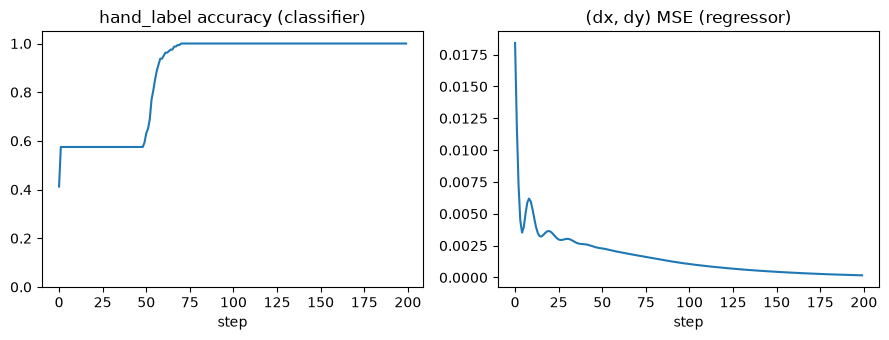

마지막 step: hand_acc=1.00, offset_mse=0.000170


In [12]:
decoder.classifier.train()
decoder.regressor.train()
classifier_opt = torch.optim.Adam(decoder.classifier.parameters(), lr=1e-3)
regressor_opt = torch.optim.Adam(decoder.regressor.parameters(), lr=1e-3)
ce_loss_fn = torch.nn.CrossEntropyLoss()
mse_loss_fn = torch.nn.MSELoss()

X_train_t = torch.from_numpy(X_train).float()
hand_train_t = torch.from_numpy(hand_train).long()
offset_train_t = torch.from_numpy(offset_train).float()

n_steps = 200
history = {"hand_acc": [], "offset_mse": []}
for step in range(n_steps):
    classifier_opt.zero_grad()
    class_logits = decoder.classifier(X_train_t)
    ce = ce_loss_fn(class_logits, hand_train_t)
    ce.backward()
    classifier_opt.step()

    regressor_opt.zero_grad()
    offset_pred = decoder.regressor(X_train_t)
    mse = mse_loss_fn(offset_pred, offset_train_t)
    mse.backward()
    regressor_opt.step()

    acc = (class_logits.argmax(dim=1) == hand_train_t).float().mean().item()
    history["hand_acc"].append(acc)
    history["offset_mse"].append(mse.item())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(history["hand_acc"])
axes[0].set_title("hand_label accuracy (classifier)")
axes[0].set_ylim(0, 1.05)
axes[1].plot(history["offset_mse"])
axes[1].set_title("(dx, dy) MSE (regressor)")
for ax in axes:
    ax.set_xlabel("step")
plt.tight_layout()
plt.show()

print(
    f"마지막 step: hand_acc={history['hand_acc'][-1]:.2f}, "
    f"offset_mse={history['offset_mse'][-1]:.6f}"
)

## 9. `N2O` 파이프라인으로 실물 팔 구동

`MixedCommand`가 팔에 대해 만드는 액션은 이름 있는 제스처가 아니라 Cartesian(`dx`, `dy`)
오프셋이라 `SO101Arm.move()`가 아직 받을 수 없습니다(5절, `ROADMAP.md`). 그래서
`n2o.robot.arm`/`n2o.robot.hand`는 둘 다 비워두고(`None`), 아래 루프가 팔을
`apply_arm_offset()`(5절, 실물 IK 구동)으로 직접 구동합니다 — `n2o.run()`은 `decode()` →
진행 상황 출력 파이프라인을 보여주는 용도로만 남습니다(`Robot.router()`는 두 파트 모두
`None`이라 아무것도 구동하지 않습니다). 손(그리퍼)은 아직 실물이 연결되지 않아 전혀
다루지 않습니다. 검증 샘플 수는 실물 첫 구동이라 `08`(3개)보다 줄였습니다.

In [ ]:
class ValidationSampleSignal:
    """검증 세트의 합성 신호를 순서대로 돌려주는 signal 소스."""

    def __init__(self, samples):
        self.samples = samples
        self.i = 0

    def read(self):
        sample = self.samples[self.i]
        self.i += 1
        return sample


N_VALID_SAMPLES = 2
samples = [X_valid[i] for i in range(N_VALID_SAMPLES)]
true_hand = [HAND_LABELS[hand_valid[i]] for i in range(N_VALID_SAMPLES)]
true_offset = [offset_valid[i] for i in range(N_VALID_SAMPLES)]

n2o = N2O()
n2o.signal = ValidationSampleSignal(samples)
n2o.decoder = decoder
n2o.command = command
# robot.arm/robot.hand는 둘 다 비워둡니다 -- 팔은 apply_arm_offset()이 직접 구동하고
# (Robot.router()가 Cartesian 오프셋을 아직 모르는 SO101Arm에 그대로 넘길 수 없으므로),
# 손은 아직 실물이 연결되지 않았습니다.

n2o.command_config = CommandConfig()
print(n2o.command_config.verify_report(n2o))

다음 셀이 실제로 팔을 움직입니다. 끝나거나 중간에 오류가 나도 항상 `arm.disconnect()`로
토크를 꺼서 마무리하도록 `try`/`finally`로 감쌌습니다.

In [ ]:
final_deg = None
try:
    for i in range(N_VALID_SAMPLES):
        predicted = decoder(samples[i])
        print(f"--- 검증 샘플 {i + 1}/{N_VALID_SAMPLES} ---")
        print(f"  실제: hand={true_hand[i]}, offset={true_offset[i].round(4)}")
        print(
            f"  예측: hand={HAND_LABELS[predicted['hand_class']]}, "
            f"dx={predicted['dx']:.4f}, dy={predicted['dy']:.4f}"
        )
        apply_arm_offset(predicted["dx"], predicted["dy"])
        n2o.run()  # robot.arm/robot.hand가 둘 다 None이라 router()는 아무것도 구동하지
        # 않습니다 -- decode -> 진행 상황 출력 파이프라인만 다시 보여줄 뿐입니다. 실제
        # 팔 구동은 위 apply_arm_offset()이 담당합니다.
    final_deg = dict(current_arm_deg)
finally:
    arm.disconnect()
    print("실물 팔 연결 해제 (토크 OFF)")

## 10. 가동범위 확인

IK로 풀어낸 관절 각도가 실제로 공식 가동범위 안에 있었는지, 9절에서 연결을 끊기 전에 읽어둔
마지막 위치(`final_deg`)로 확인합니다 -- `SO101IKSolver.solve()`가 매 반복마다 이미
clamp하므로, 여기서는 그게 실제로 지켜졌는지 다시 한번 직접 확인하는 것입니다.

In [ ]:
print("관절별 가동범위 확인 (공식 벤더 값 기준, 실물 최종 위치):")
final_rad = real_deg_to_mj_rad(final_deg)
for joint in ARM_JOINTS:
    joint_id = mujoco.mj_name2id(ik_solver.model, mujoco.mjtObj.mjOBJ_JOINT, joint)
    lo, hi = ik_solver.model.jnt_range[joint_id]
    value = final_rad[joint]
    status = "OK" if lo - 1e-6 <= value <= hi + 1e-6 else "범위 초과"
    print(
        f"  {joint:14s}: {value:6.3f} rad ({final_deg[joint]:+7.2f}°)   "
        f"(공식 범위 [{lo:6.3f}, {hi:6.3f}])   {status}"
    )

## 정리

- `MixedDecoder`/`MixedCommand`는 `08`과 완전히 동일합니다 -- 실물이냐 시뮬레이션이냐는
  팔을 실제로 구동하는 코드 쪽에만 영향을 줄 뿐, 디코더가 무엇을 예측하고 커맨드가 어떻게
  태그하는지는 전혀 바뀌지 않습니다.
- 이번 노트북의 핵심은 `apply_arm_offset()`입니다 -- `08`과 같은 `SO101IKSolver`(감쇠
  최소제곱 IK, 매 반복 공식 `jnt_range` clamp)를 그대로 재사용하고, "현재 위치"만
  시뮬레이션이 아니라 실물 `get_observation()`에서 읽습니다. `SO101Arm`이 아직 Cartesian
  오프셋을 모르므로(`ROADMAP.md`) `Robot.router()`를 거치지 않고, 1절에서 이미 연결해 둔
  저수준 `arm.send_action()`으로 직접 전송합니다. 목표 관절각은 여러 단계로 나눠 점진적으로
  보내고(이동 거리 / 1cm/s로 스텝 수를 동적으로 계산), `SO101Follower5DofConfig.
  max_relative_target`이 2차 안전장치로 동작합니다.
- 반대로 이산 제스처(`"up"`/`"down"`)는 `n2o.robot.arm.so101.SO101Arm.move()`가 직접
  구동합니다 -- 관절-각도 공간에서 안전 속도로 램프하는 로직이 이미 그 안에 내장돼 있어서,
  이 노트북이 따로 구현할 게 없습니다.
- `n2o.robot.hand`는 이 노트북에서 한 번도 설정되지 않습니다 -- 실물 그리퍼(또는 그 자리에
  붙일 타사 로봇손) 연동은 이번 범위 밖이며, 다음 단계에서 별도로 다룹니다.
- `n2o.robot.arm`/`n2o.robot.hand`도 9절의 `N2O` 파이프라인 자체에서는 둘 다 `None`으로
  남습니다 -- 이 노트북의 `MixedCommand`가 팔에 대해 만드는 액션(Cartesian 오프셋)을
  `SO101Arm`이 아직 받을 수 없기 때문입니다(`ROADMAP.md`). `n2o.run()`은 `decode()` ->
  진행 상황 출력 파이프라인만 보여줄 뿐, 실제 팔 구동은 `apply_arm_offset()`이 담당합니다.
  `src/n2o/`는 이 노트북에서 전혀 바뀌지 않았습니다.